In [2]:
import os
import sys

import numpy as np
import pandas as pd

import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

import seaborn as sns
import matplotlib.pyplot as plt

import umap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

In [3]:
SEED = 42
PLOT_DPI = 100

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv"

In [4]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.205773,0.010205,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.189188,0.009251,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.174736,0.006552,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly


In [5]:
dataframe_X = dataframe.drop(columns=["anomaly", "description"])
dataframe_y = dataframe[["anomaly"]]

dataframe_X.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.735566,0.000454,0.205773,0.010205,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.732637,0.000459,0.189188,0.009251,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.732090,0.000465,0.174736,0.006552,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataframe_X.to_numpy())
X_scaled

array([[ 5.77936804e-01,  7.79183394e-01,  6.45772145e-01, ...,
        -1.19787338e-01,  1.23240803e+00,  5.32112030e-01],
       [ 5.83911406e-01,  7.97831521e-01,  5.33472897e-01, ...,
        -1.19787338e-01,  1.23240803e+00,  5.32112030e-01],
       [ 5.83911406e-01,  7.97831521e-01,  5.33472897e-01, ...,
        -1.19787338e-01,  1.23240803e+00,  5.32112030e-01],
       ...,
       [-7.98123326e-01, -8.51185923e-01, -1.33261506e+00, ...,
        -4.40524476e-02, -9.26493669e-01, -5.04486097e-01],
       [-7.99511102e-01, -8.56035264e-01, -8.30555100e-01, ...,
        -2.30295131e-02, -7.92233124e-01, -4.67367495e-01],
       [-8.01906453e-01, -8.43912946e-01, -1.37053983e+00, ...,
         9.68116055e-04, -7.88997164e-01, -2.15698791e-01]],
      shape=(49202, 28))

## Linear Dimensionality Reduction Techniques

### Principal Component Analysis (PCA)

In [7]:
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print("PCA reduced data shape:", X_pca.shape)
dataframe_pca = pd.DataFrame(X_pca[:, :2], columns=["Principal_Component_1", "Principal_Component_2"])
dataframe_pca = dataframe_pca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_pca

PCA reduced data shape: (49202, 28)


,Principal_Component_1,Principal_Component_2,anomaly,description
0,3.598919,-0.795441,0.0,No Anomaly
1,2.826847,0.250835,0.0,No Anomaly
2,2.826847,0.250835,0.0,No Anomaly
3,3.830020,-0.689370,0.0,No Anomaly
4,3.497207,0.352113,0.0,No Anomaly
...,...,...,...,...
49197,-3.211767,0.197637,0.0,No Anomaly
49198,-3.213268,0.191861,0.0,No Anomaly
49199,-4.025613,-1.033407,0.0,No Anomaly
49200,-3.372434,0.825238,0.0,No Anomaly


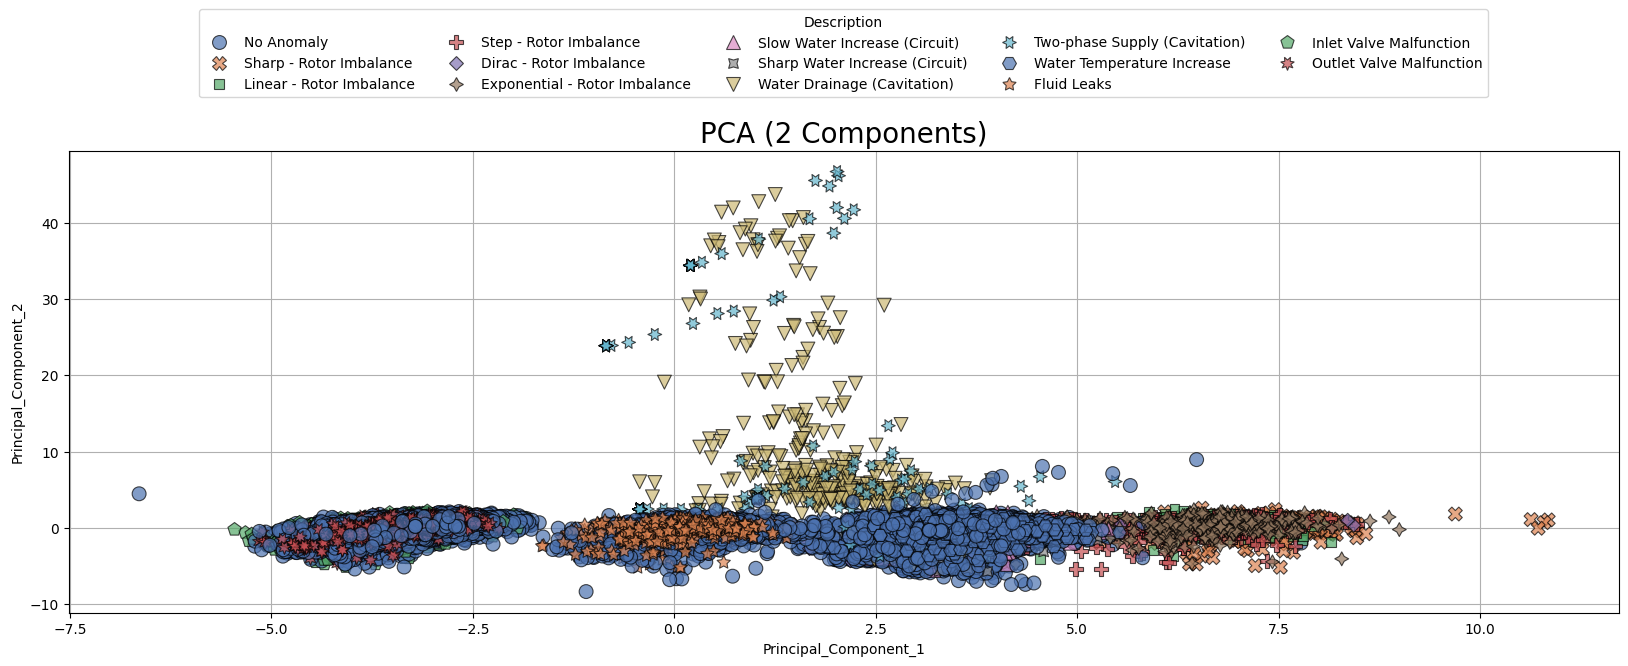

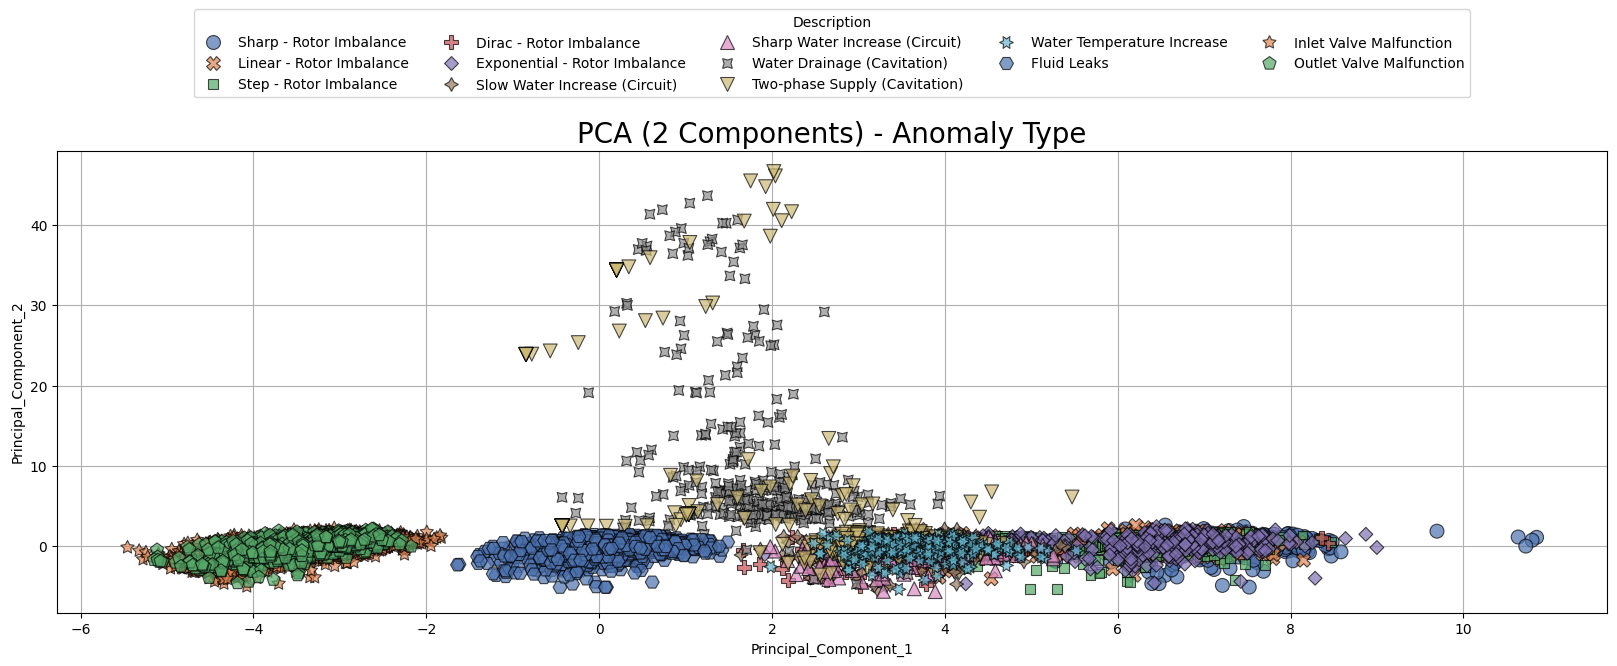

In [8]:
plot.plot_dimensional_reduction(dataframe_pca, title="PCA (2 Components)")
plot.plot_dimensional_reduction(dataframe_pca.iloc[np.where(dataframe_pca.anomaly!=0.0)], title="PCA (2 Components) - Anomaly Type")

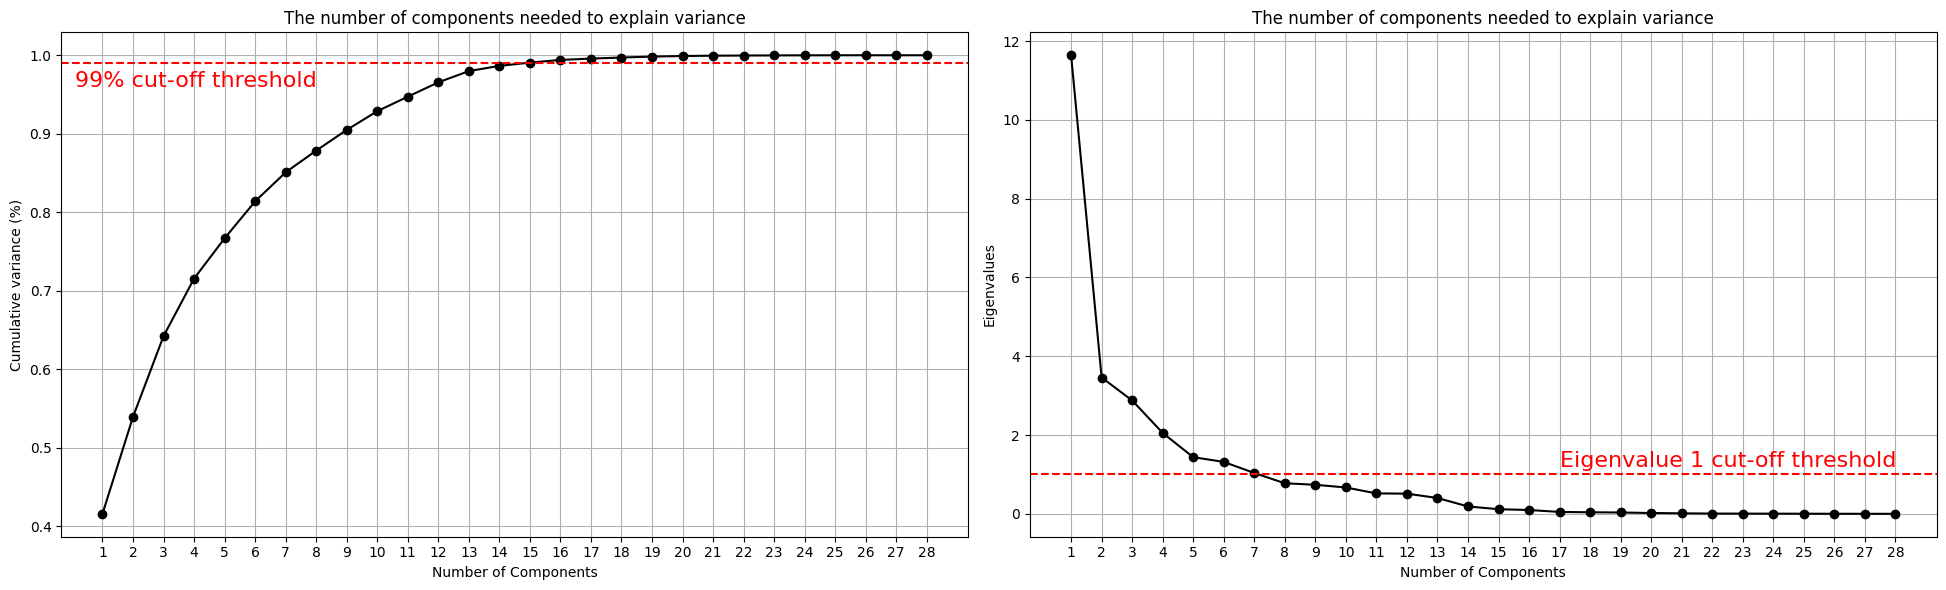

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

xi = np.arange(1, X_scaled.shape[1]+1, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

axs[0].plot(xi, y, marker='o', linestyle='-', color='black')

# axs[0].set_ylim(0.0,1.1)
axs[0].set_xlabel('Number of Components')
axs[0].set_xticks(np.arange(1, X_scaled.shape[1]+1, step=1)) 
axs[0].set_ylabel('Cumulative variance (%)')
axs[0].set_title('The number of components needed to explain variance')

axs[0].axhline(y=0.99, color='red', linestyle='--')
axs[0].text(0.1, 0.96, '99% cut-off threshold', color = 'red', fontsize=16)

axs[0].grid(True)

# axs[1].ylim(0.0,max(pca.explained_variance_))
axs[1].plot(xi, pca.explained_variance_, marker='o', linestyle='-', color='black')

axs[1].set_xlabel('Number of Components')
axs[1].set_xticks(np.arange(1, X_scaled.shape[1]+1, step=1)) 
axs[1].set_ylabel('Eigenvalues')
axs[1].set_title('The number of components needed to explain variance')

axs[1].axhline(y=1, color='red', linestyle='--')
axs[1].text(17, 1.2, 'Eigenvalue 1 cut-off threshold', color = 'red', fontsize=16)

axs[1].grid(True)


plt.tight_layout()
plt.show()

### Linear Discriminant Analysis (LDA)

In [10]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, dataframe_y.to_numpy().ravel())

print("LDA reduced data shape:", X_lda.shape)
dataframe_lda = pd.DataFrame(X_lda, columns=["Linear_Discriminant_1", "Linear_Discriminant_2"])
dataframe_lda = dataframe_lda.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_lda

LDA reduced data shape: (49202, 2)


,Linear_Discriminant_1,Linear_Discriminant_2,anomaly,description
0,-0.562462,-0.287713,0.0,No Anomaly
1,-0.523552,-0.094059,0.0,No Anomaly
2,-0.523552,-0.094059,0.0,No Anomaly
3,-0.645048,-0.063463,0.0,No Anomaly
4,-0.575545,0.004856,0.0,No Anomaly
...,...,...,...,...
49197,-0.784416,-0.512660,0.0,No Anomaly
49198,-0.786232,-0.506333,0.0,No Anomaly
49199,-0.735085,-0.378920,0.0,No Anomaly
49200,-0.825639,-0.275191,0.0,No Anomaly


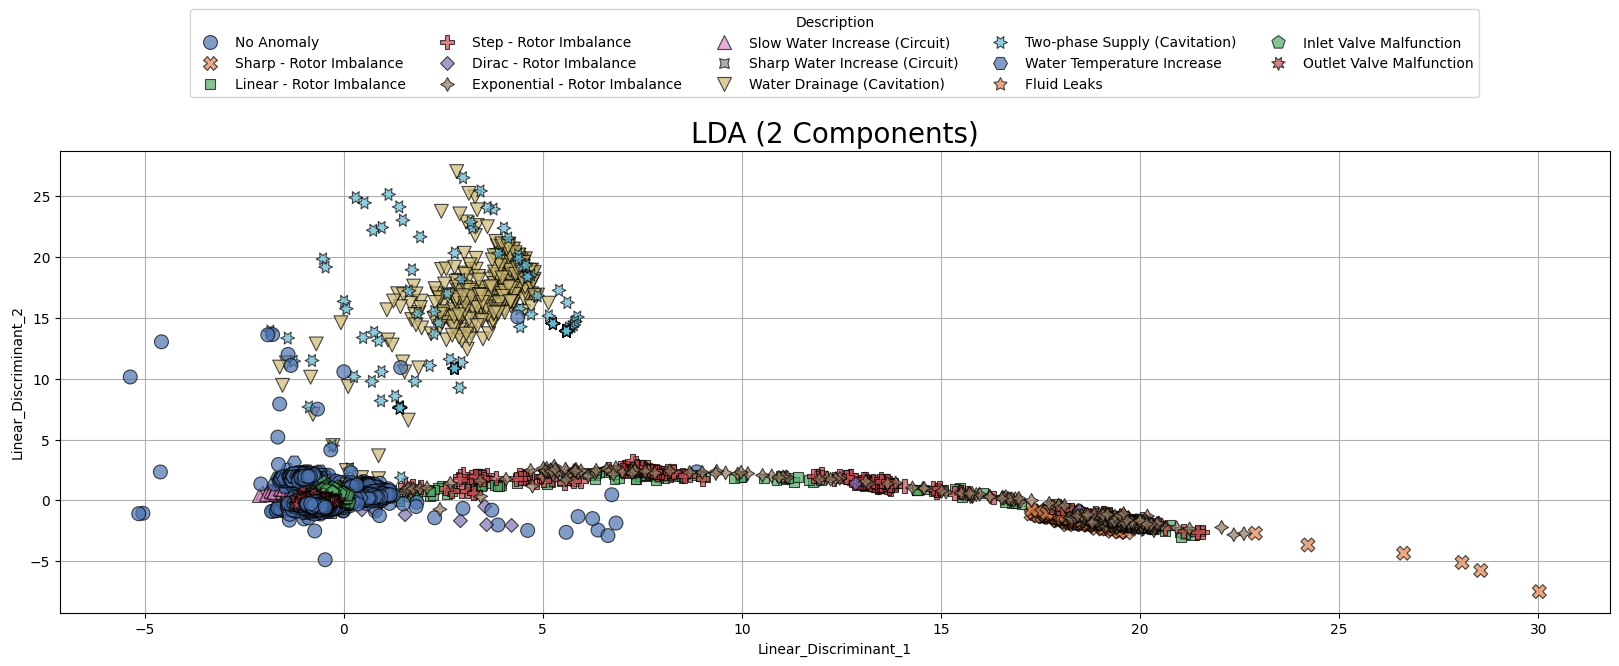

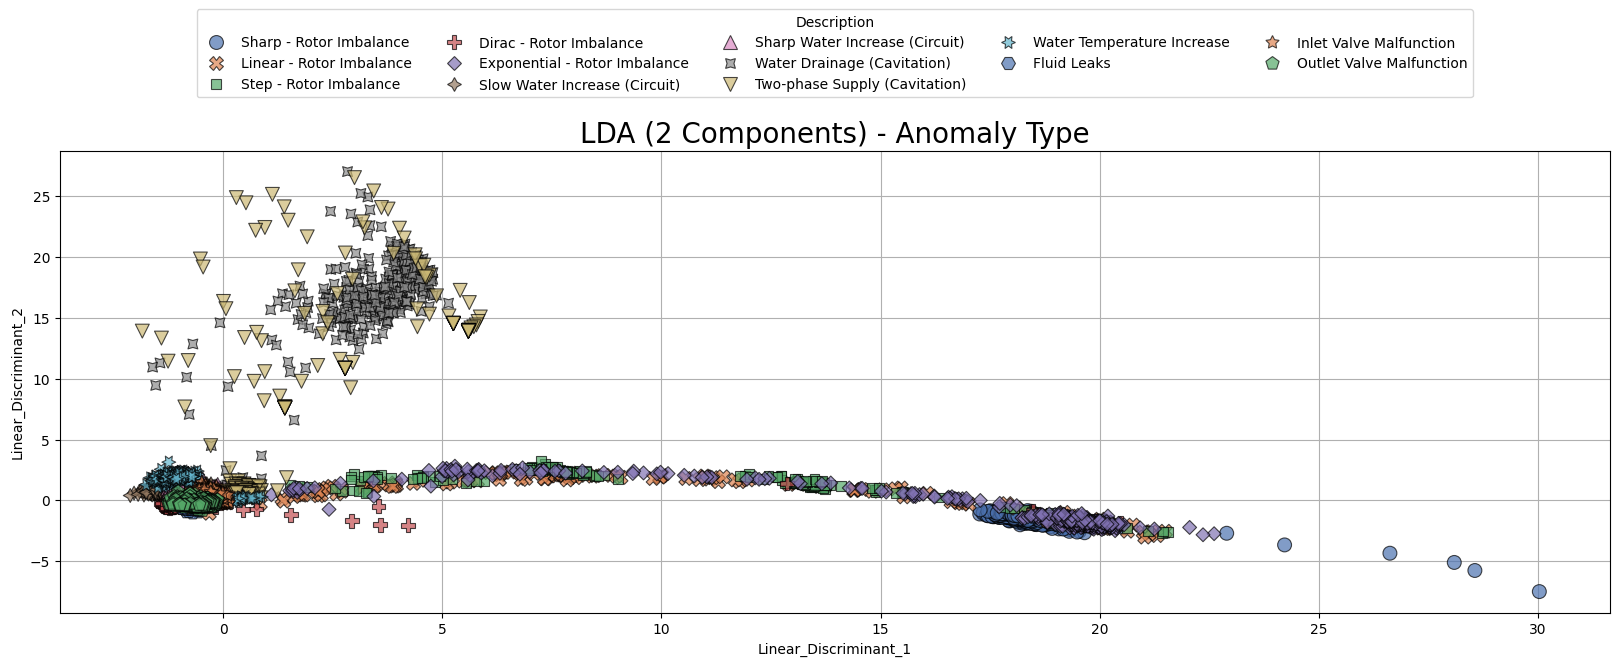

In [11]:
plot.plot_dimensional_reduction(dataframe_lda, title="LDA (2 Components)")
plot.plot_dimensional_reduction(dataframe_lda.iloc[np.where(dataframe_lda.anomaly!=0.0)], title="LDA (2 Components) - Anomaly Type")

### Non-Negative Matrix Factorization (NMF)

In [12]:
# For NMF, the input data must be non-negative.
X_nmf_positive = dataframe_X.to_numpy() - dataframe_X.to_numpy().min() # Simple way to make it non-negative for demo
nmf = NMF(n_components=2, init='random', random_state=SEED, max_iter=500)
X_nmf = nmf.fit_transform(X_nmf_positive)

print("NMF reduced data shape:", X_nmf.shape)
dataframe_nmf = pd.DataFrame(X_nmf, columns=["NMF_Component_1", "NMF_Component_2"])
dataframe_nmf = dataframe_nmf.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_nmf

NMF reduced data shape: (49202, 2)


,NMF_Component_1,NMF_Component_2,anomaly,description
0,2.980529,12.011873,0.0,No Anomaly
1,3.352667,10.061877,0.0,No Anomaly
2,3.352667,10.061877,0.0,No Anomaly
3,2.250718,12.773323,0.0,No Anomaly
4,2.743955,12.944495,0.0,No Anomaly
...,...,...,...,...
49197,6.865214,4.059613,0.0,No Anomaly
49198,6.867456,4.064207,0.0,No Anomaly
49199,10.515697,1.713442,0.0,No Anomaly
49200,7.160715,4.009331,0.0,No Anomaly


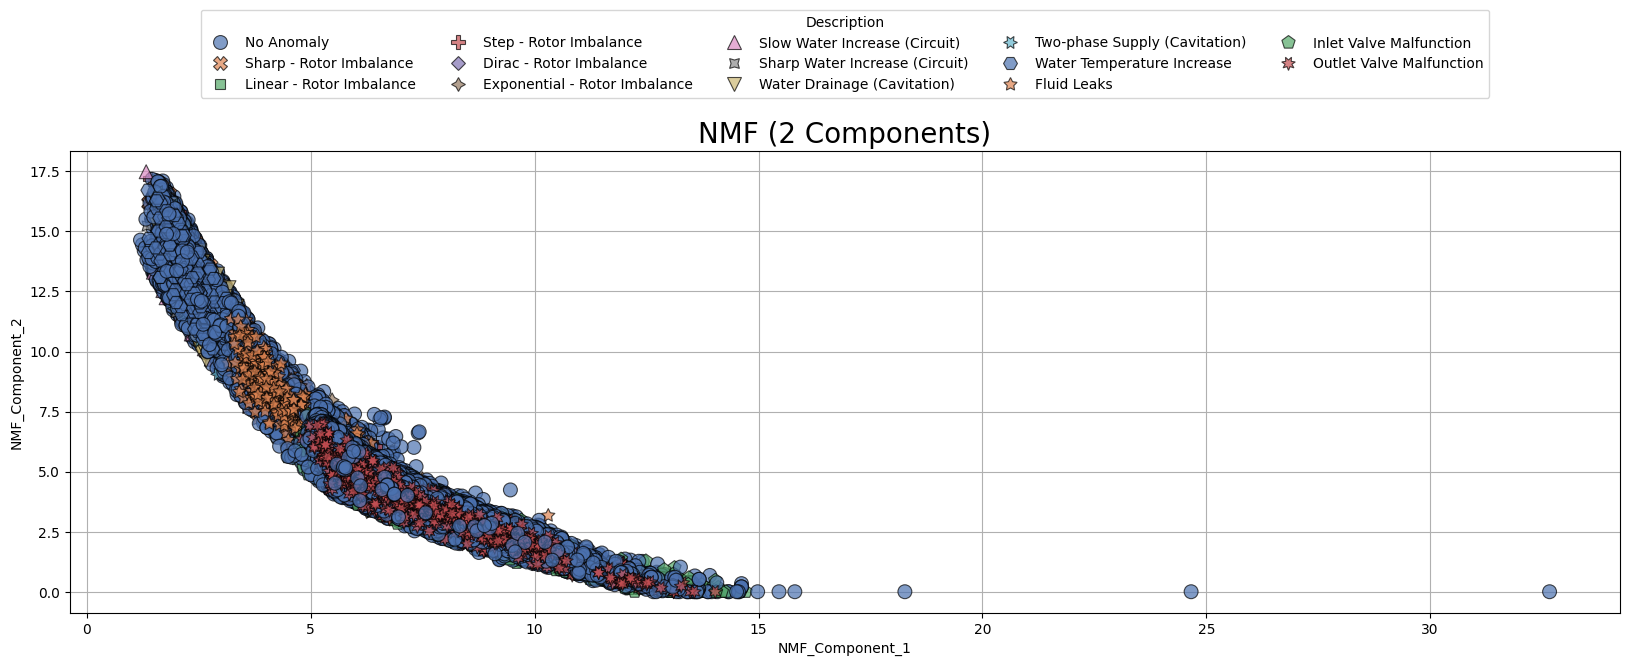

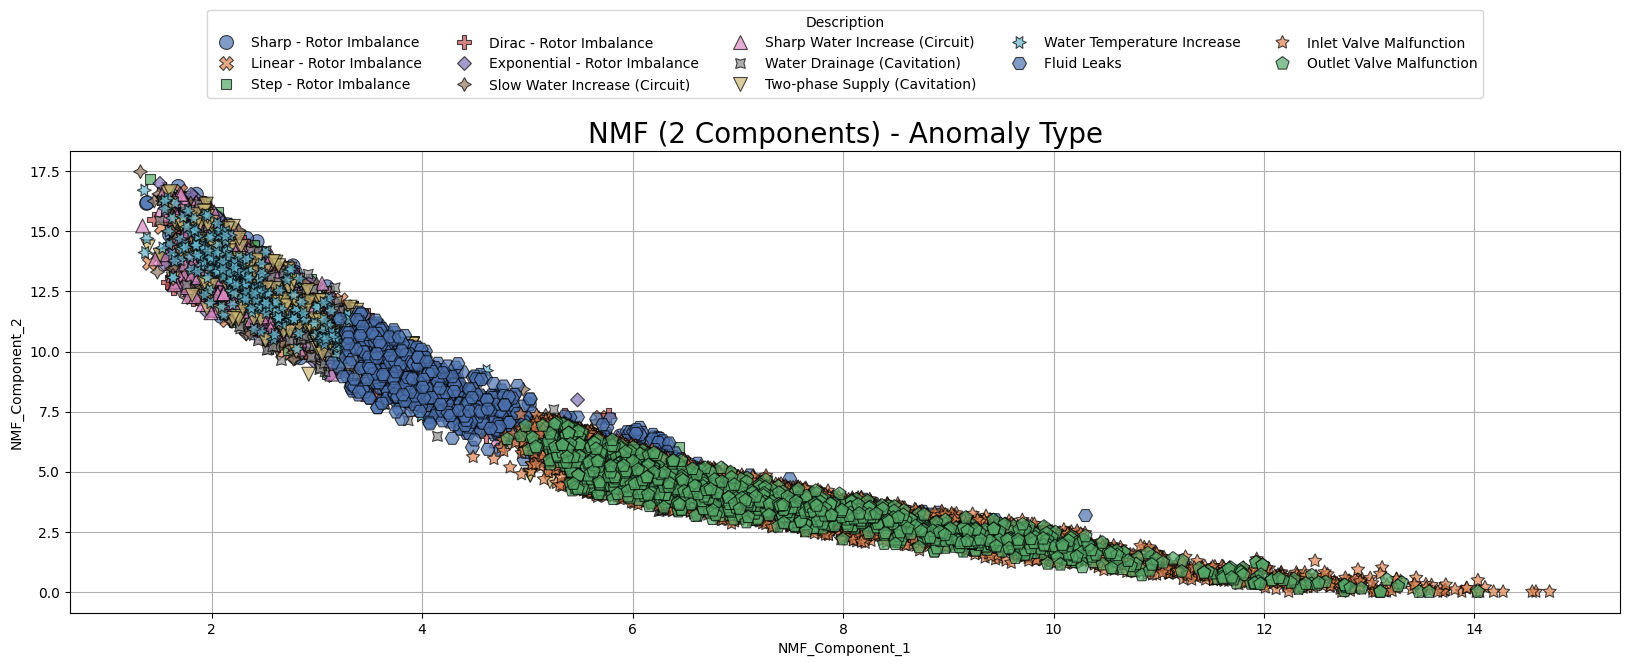

In [13]:
plot.plot_dimensional_reduction(dataframe_nmf, title="NMF (2 Components)")
plot.plot_dimensional_reduction(dataframe_nmf.iloc[np.where(dataframe_nmf.anomaly!=0.0)], title="NMF (2 Components) - Anomaly Type")

## Non-linear Dimensionality Reduction Techniques

### t-Distributed Stochastic Neighbor Embedding (t-SNE)

In [14]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_jobs=5)
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE reduced data shape:", X_tsne.shape)
dataframe_tsne = pd.DataFrame(X_tsne, columns=["tSNE_Component_1", "tSNE_Component_2"])
dataframe_tsne = dataframe_tsne.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_tsne

t-SNE reduced data shape: (49202, 2)


,tSNE_Component_1,tSNE_Component_2,anomaly,description
0,48.468880,-39.546883,0.0,No Anomaly
1,10.375680,82.975319,0.0,No Anomaly
2,10.375680,82.975319,0.0,No Anomaly
3,63.926468,-52.552216,0.0,No Anomaly
4,45.785091,42.706841,0.0,No Anomaly
...,...,...,...,...
49197,-37.770916,6.895110,0.0,No Anomaly
49198,-37.815014,7.007590,0.0,No Anomaly
49199,-81.789322,-1.132953,0.0,No Anomaly
49200,-34.658455,66.705788,0.0,No Anomaly


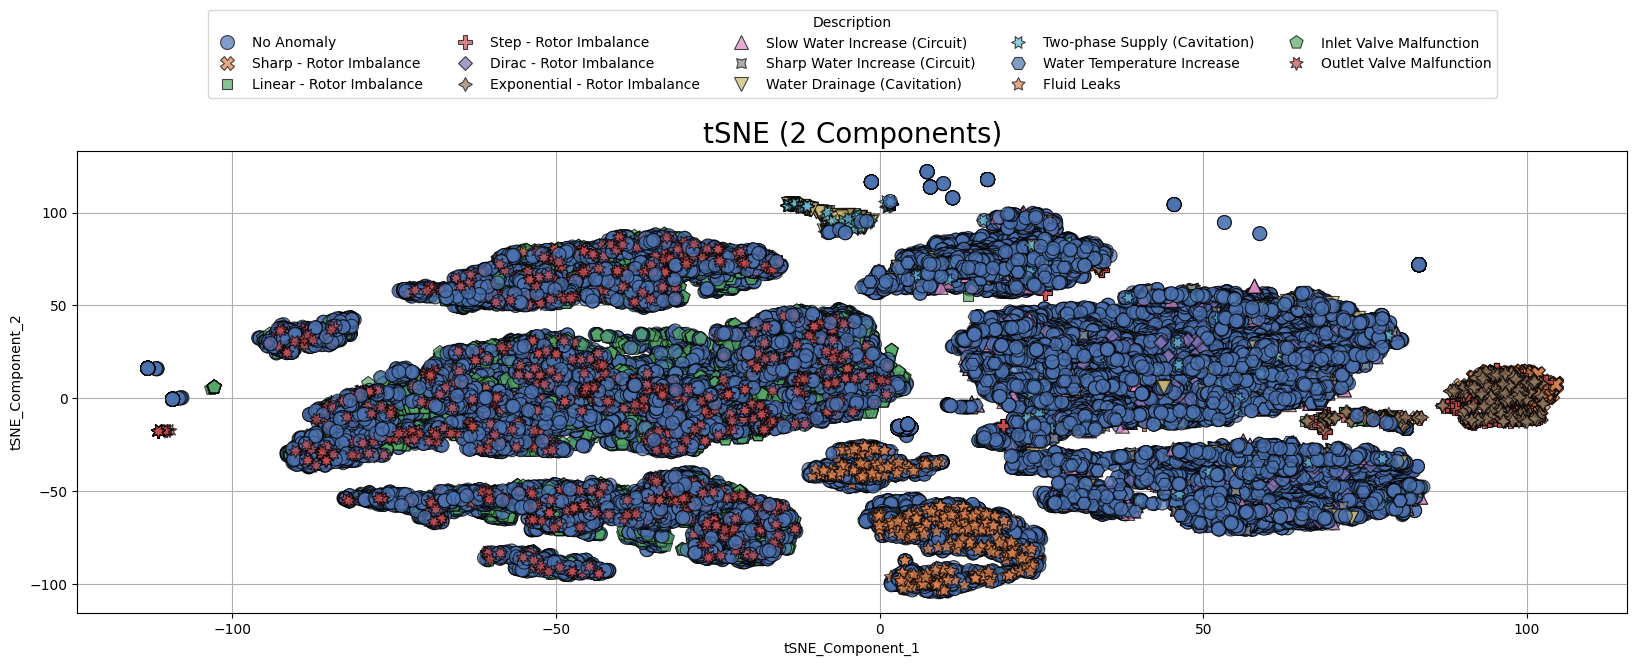

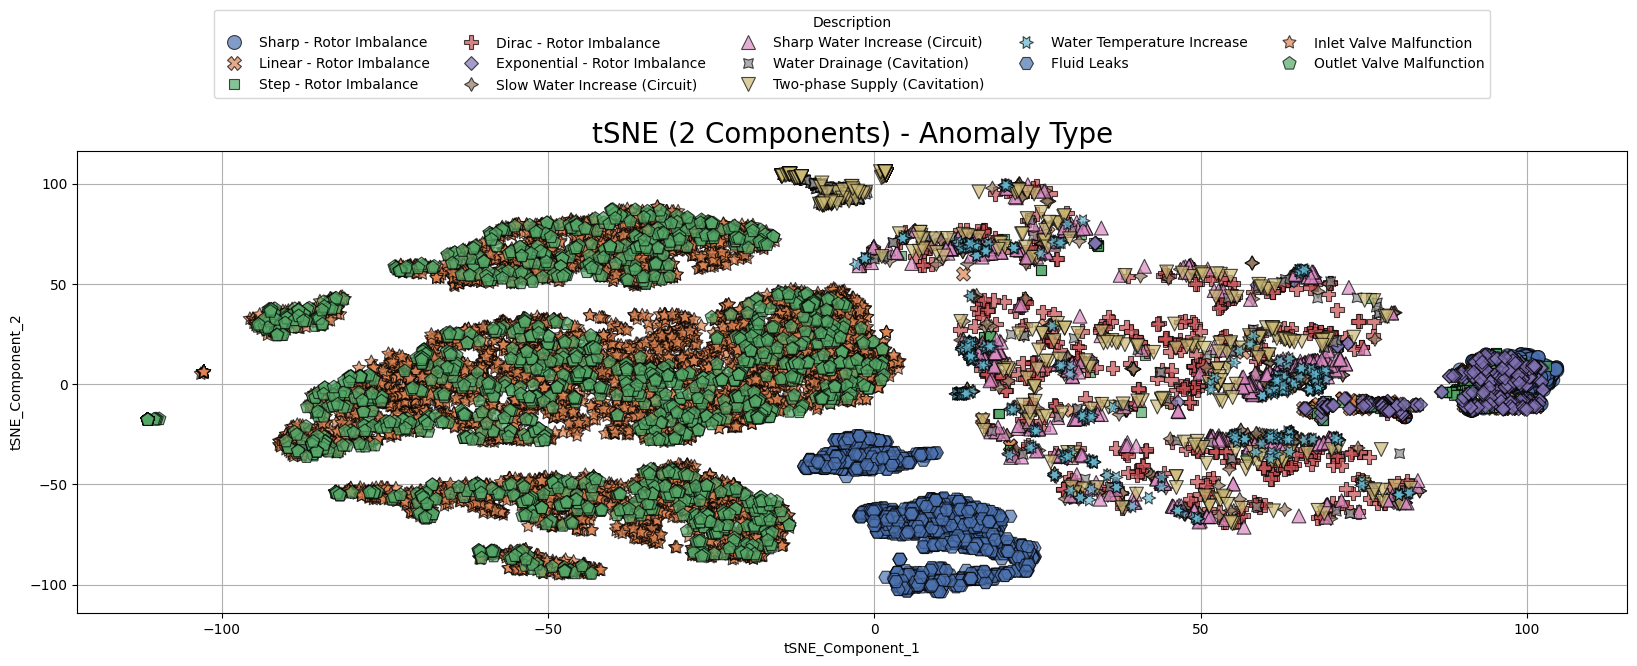

In [15]:
plot.plot_dimensional_reduction(dataframe_tsne, title="tSNE (2 Components)")
plot.plot_dimensional_reduction(dataframe_tsne.iloc[np.where(dataframe_tsne.anomaly!=0.0)], title="tSNE (2 Components) - Anomaly Type")

### Uniform Manifold Approximation and Projection (UMAP)

In [16]:
reducer = umap.UMAP(n_components=2, random_state=SEED)
X_umap = reducer.fit_transform(X_scaled)

print("UMAP reduced data shape:", X_umap.shape)
dataframe_umap = pd.DataFrame(X_umap, columns=["UMAP_Component_1", "UMAP_Component_2"])
dataframe_umap = dataframe_umap.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_umap

UMAP reduced data shape: (49202, 2)


,UMAP_Component_1,UMAP_Component_2,anomaly,description
0,-2.748523,13.005202,0.0,No Anomaly
1,3.121426,7.713439,0.0,No Anomaly
2,3.117834,7.719520,0.0,No Anomaly
3,-3.009170,13.072396,0.0,No Anomaly
4,-3.918372,2.924715,0.0,No Anomaly
...,...,...,...,...
49197,14.643564,3.930935,0.0,No Anomaly
49198,14.702619,3.979147,0.0,No Anomaly
49199,13.096154,7.165589,0.0,No Anomaly
49200,13.335740,16.841532,0.0,No Anomaly


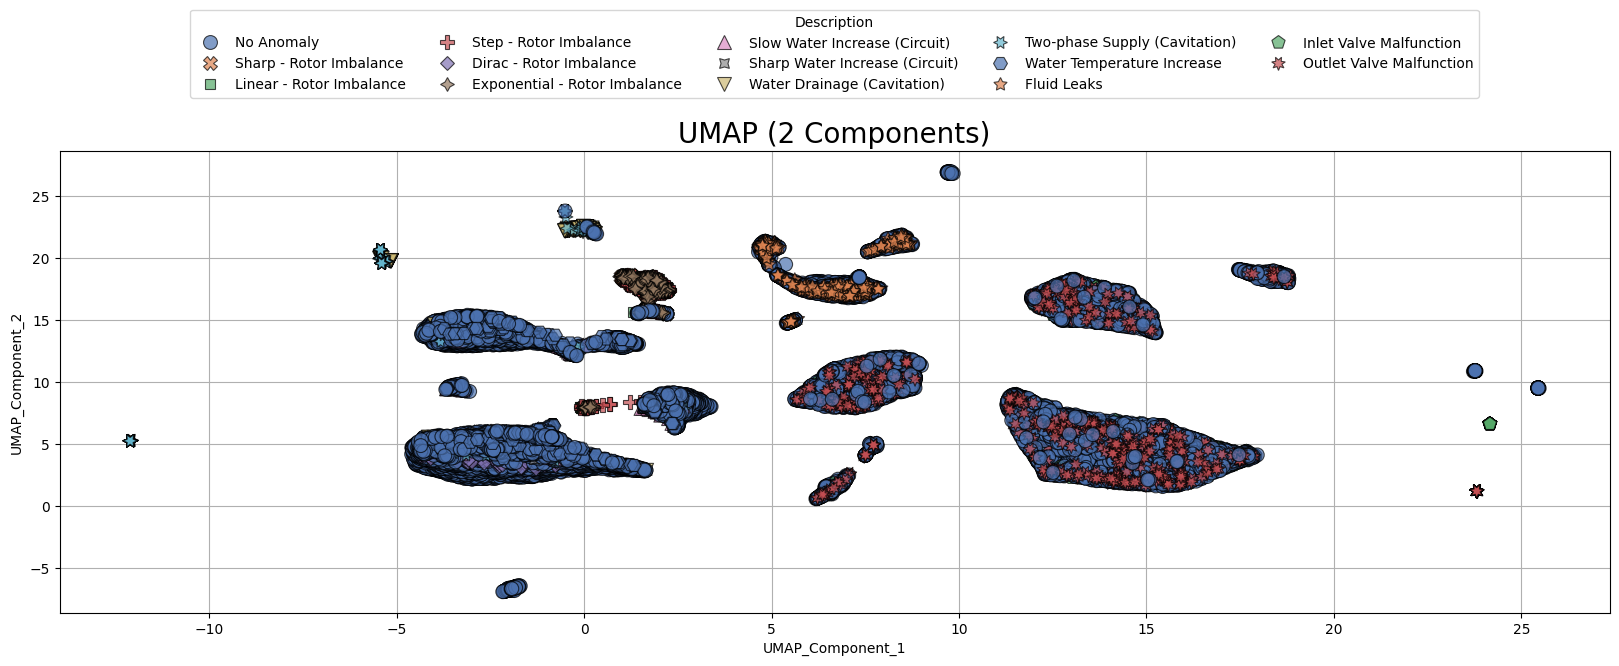

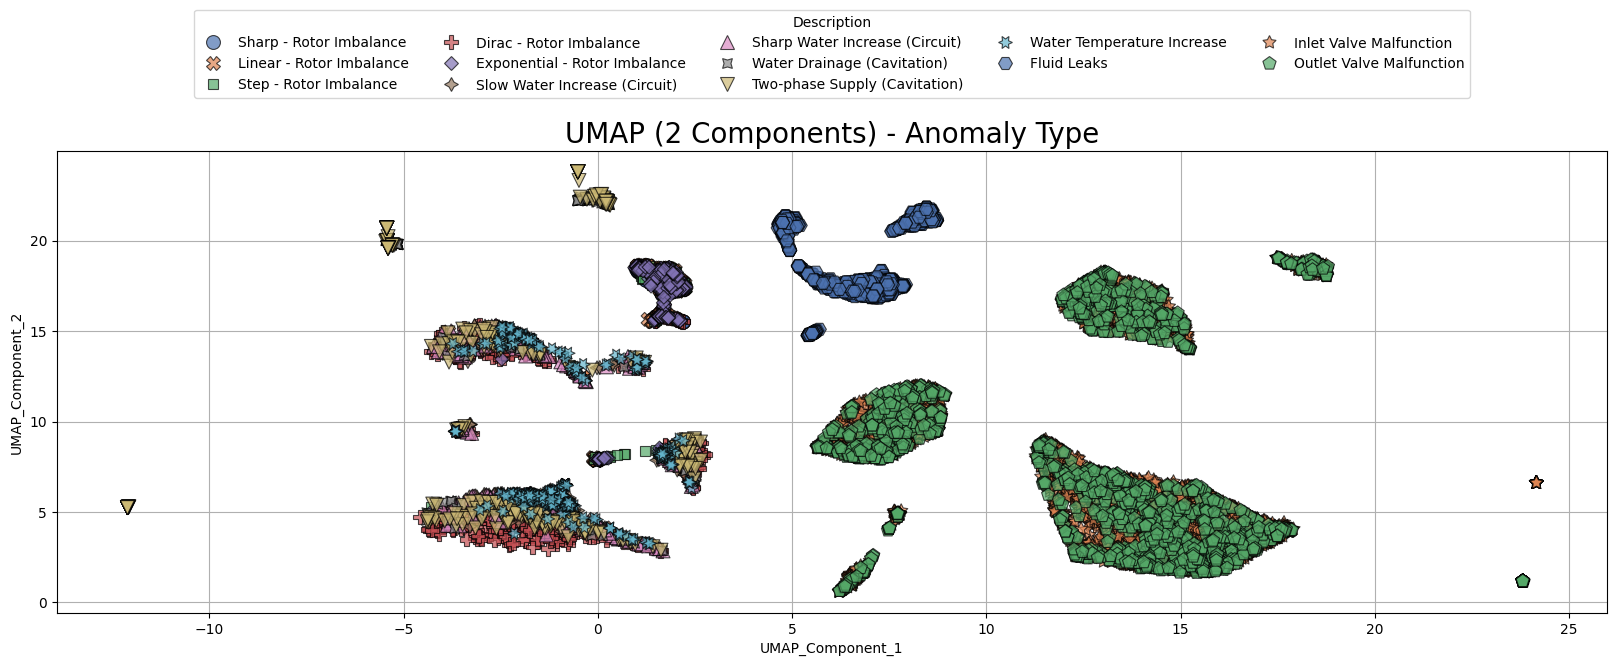

In [17]:
plot.plot_dimensional_reduction(dataframe_umap, title="UMAP (2 Components)")
plot.plot_dimensional_reduction(dataframe_umap.iloc[np.where(dataframe_umap.anomaly!=0.0)], title="UMAP (2 Components) - Anomaly Type")

### Kernel Principal Component Analysis (KPCA)

In [18]:
kpca = KernelPCA(n_components=2, kernel="rbf", random_state=SEED)
X_kpca = kpca.fit_transform(X_scaled)

print("Kernel PCA reduced data shape:", X_kpca.shape)
dataframe_kpca = pd.DataFrame(X_kpca, columns=["K_Principal_Component_1", "K_Principal_Component_2"])
dataframe_kpca = dataframe_kpca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_kpca

Kernel PCA reduced data shape: (49202, 2)


,K_Principal_Component_1,K_Principal_Component_2,anomaly,description
0,0.555578,0.065800,0.0,No Anomaly
1,0.483090,0.014228,0.0,No Anomaly
2,0.483090,0.014228,0.0,No Anomaly
3,0.583531,0.053085,0.0,No Anomaly
4,0.550073,-0.032913,0.0,No Anomaly
...,...,...,...,...
49197,-0.569629,-0.132295,0.0,No Anomaly
49198,-0.568458,-0.130739,0.0,No Anomaly
49199,-0.477794,0.347383,0.0,No Anomaly
49200,-0.509906,-0.221443,0.0,No Anomaly


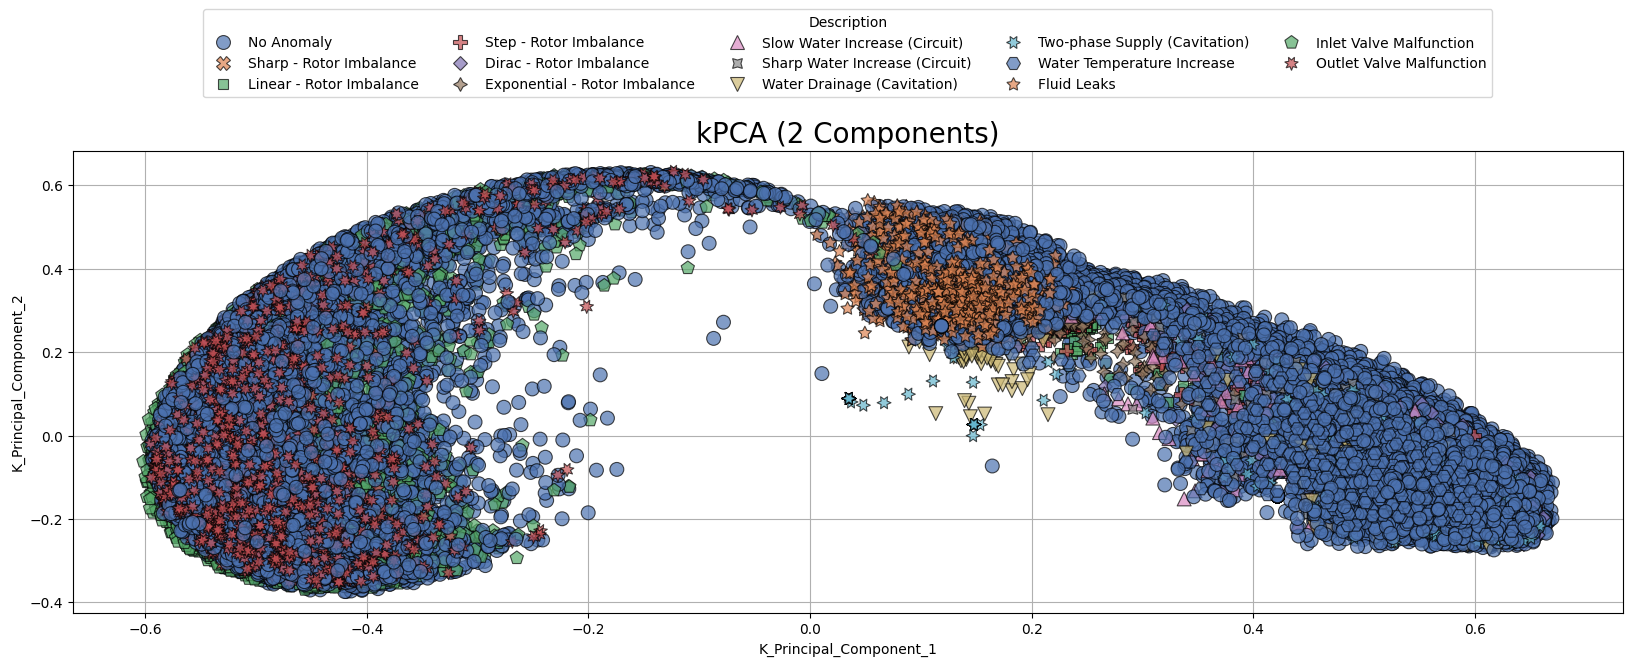

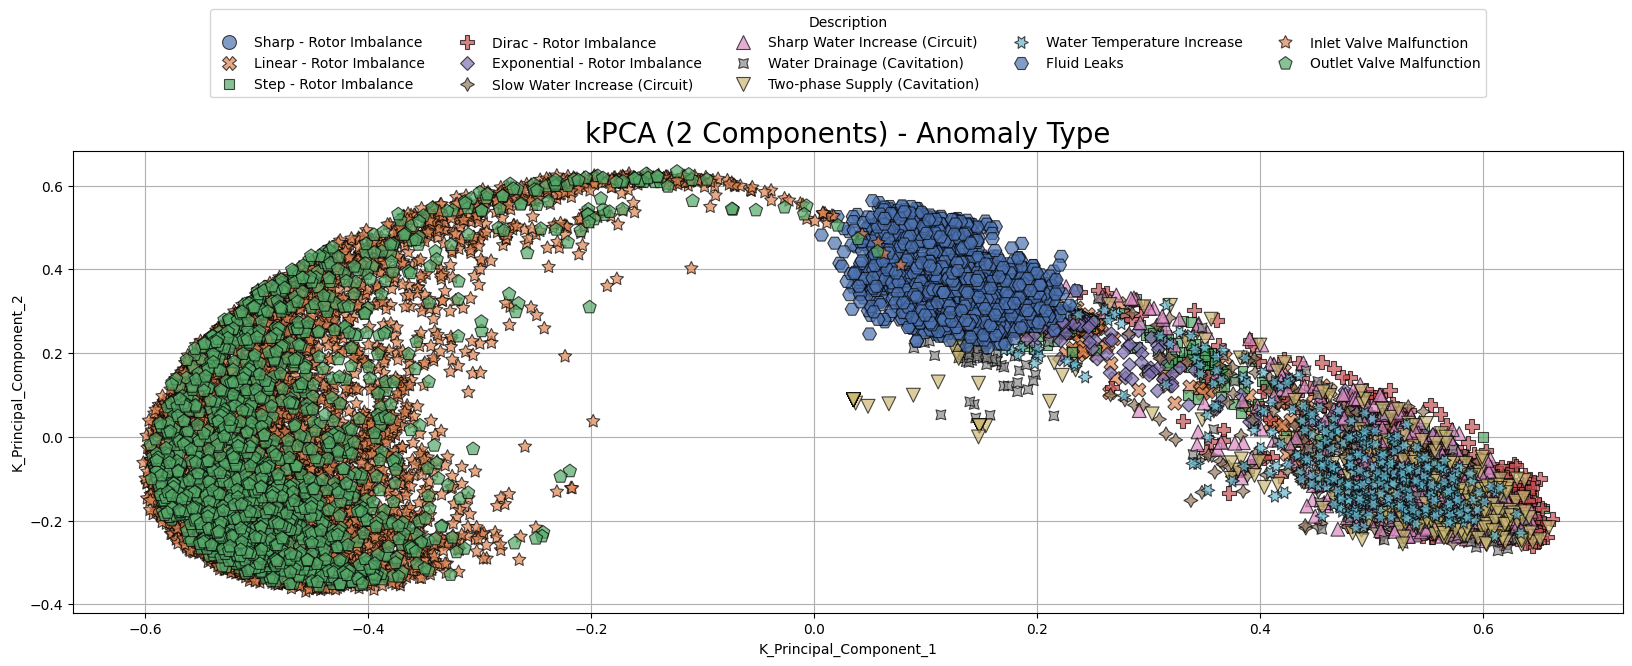

In [19]:
plot.plot_dimensional_reduction(dataframe_kpca, title="kPCA (2 Components)")
plot.plot_dimensional_reduction(dataframe_kpca.iloc[np.where(dataframe_kpca.anomaly!=0.0)], title="kPCA (2 Components) - Anomaly Type")

In [20]:
kpca.eigenvalues_

array([11223.91445248,  2693.50211844])

Hello! It's a common challenge to work with imbalanced anomaly detection datasets. The goal is to generate new, synthetic anomalies that are similar to your existing ones to balance the data without just duplicating the rare examples. This helps your model learn the unique characteristics of each anomaly type.

Here are the main techniques you can use to augment your dataset with synthetic anomalies.

### Sampling-Based Techniques 📈

These methods work directly on your existing data points to create new, synthetic ones. They are often simpler and less computationally expensive than generative models.

---

**1. SMOTE (Synthetic Minority Oversampling Technique)**
SMOTE works by selecting a minority class example (one of your 13 anomaly types) and finding its nearest neighbors. It then draws a line between the example and its neighbors and creates a new, synthetic data point at a random position along that line. 
* **How it helps:** You can apply SMOTE to each of your 13 anomaly types individually to generate more examples for each class. This helps "fill in the gaps" in the data distribution of the rare classes.

**2. ADASYN (Adaptive Synthetic Sampling)**
ADASYN is an improved version of SMOTE. It focuses on generating synthetic data for minority examples that are harder to learn, meaning those that are closer to the decision boundary of the majority (normal) class.
* **How it helps:** For your dataset, ADASYN would be particularly useful for anomalies that are very subtle or difficult to distinguish from normal data. It will create more synthetic examples in these challenging regions, helping your model learn to detect them more accurately.

***

### Generative Modeling Techniques 🧠

These methods use machine learning models to learn the underlying distribution of your data and then generate entirely new data points from scratch. This can produce more diverse and realistic anomalies than sampling-based methods.

---

**1. Variational Autoencoders (VAEs)**
A VAE is a neural network that learns to compress your data into a "latent space," which is a simplified, continuous representation. Once it learns the pattern of your anomalies, you can sample new points from this latent space and "decompress" them to generate novel synthetic anomalies.
* **How it helps:** You can train a VAE on each of your 13 anomaly types. The model will learn the core features of, for example, "Anomaly Type A." You can then use this trained model to generate many new, unique examples that look and behave like "Anomaly Type A."

**2. Generative Adversarial Networks (GANs)**
A GAN consists of two competing neural networks: a **Generator** and a **Discriminator**. The Generator creates synthetic data, and the Discriminator tries to distinguish the real data from the synthetic data. Through this adversarial process, the Generator gets better and better at creating realistic data that can fool the Discriminator.
* **How it helps:** You can train a GAN to generate anomalies for each of your 13 classes. The generator will learn to create new anomalies that are so realistic that they are indistinguishable from the actual anomalies in your dataset. This is a powerful way to create a large, diverse set of synthetic examples. The challenge here is to avoid "mode collapse," where the GAN only learns to generate a few types of anomalies.

***

### Hybrid and Other Approaches 🧪

These techniques combine different ideas or use an alternative approach to increase the number of anomalies.

---

**1. Anomaly-Specific Perturbation**
This method involves taking an existing anomaly example and making small, meaningful changes to it to create a new one. For instance, if an anomaly is characterized by a sudden spike in a sensor reading, you can create new examples by slightly changing the magnitude, duration, or timing of that spike.
* **How it helps:** This is a simple, effective way to create subtle variations within each of your 13 anomaly types without needing a complex model.

**2. Synthetic Anomaly Injection**
If you have a good understanding of what constitutes a "normal" data point, you can programmatically inject anomalies into normal data. For example, you could add a simulated spike, a sudden shift in a value, or a missing data point to a normal data sequence.
* **How it helps:** This method is very flexible and allows you to create an unlimited number of synthetic anomalies that are guaranteed to be different from the normal data. However, it requires significant domain expertise to ensure the generated anomalies are realistic and not just random noise.